# Unsupervised learning

Examples of unsupervised learning:

1. Dimensionality reduction (Discussed in the previous chapter).
2. Clustering: grouping similar instances together into clusters. 
3. Anomaly detection: Learning what 'normal' data looks like so that the model can detect abnormal data.
4. Density estimation: estimating the probability density function (PDF) of the random process that generated the dataset. 

## Clustering

Clustering simply tries to assign similar clusters the same label without knowing the labels beforehand. 

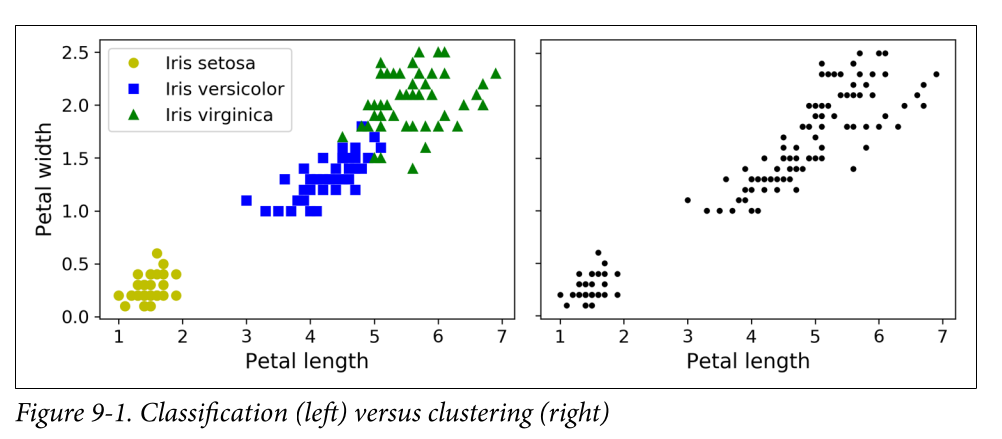

Clustering is used in a wide variety of applications, including:
1. Customer segmentation: clustering customers based on their purchases and their activity on a website.
2. Data analysis.
3. Dimensionality reduction: After clustering the data, it is possible to calculate the _affinity_ of each instance to each cluster. This results in a vector of affinities of size _k_, which is much lower-dimensional than the original feature space of the instances.
4. Anomaly detection (outlier detection): Any instance that has a low affinity to all clusters is likely to be an anomaly. 
5. Semi-supervised learning: If you have a few labels, you could perform clustering and propagate the labels to all the instances in the same cluster.
6. Search engines: Some search engines let you search for images that are similar to a reference image. 
7. Image segmentation: By clustering pixels according to their color, then replacing each pixel's color with the mean color of its cluster.  

## K-Means
K means is suitable for clustering datasets that look like the following:

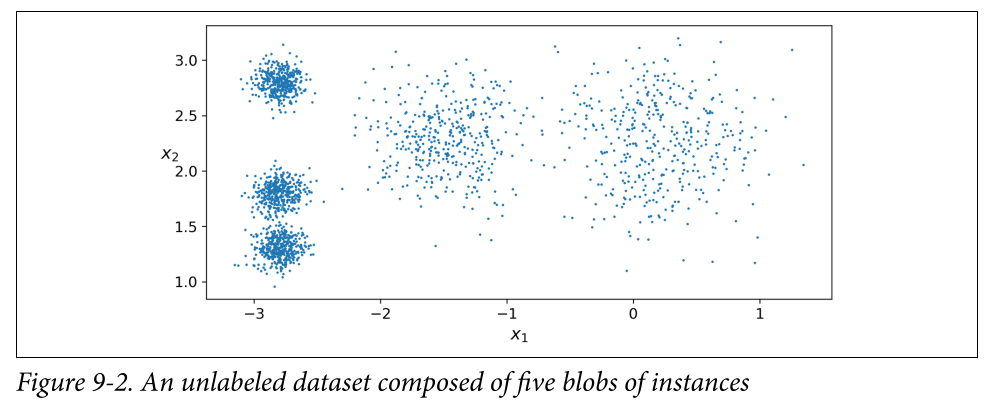

You can clearly see that there are 5 blobs of instances in the dataset, which means that it is possible to cluster this dataset into 5 clusters.

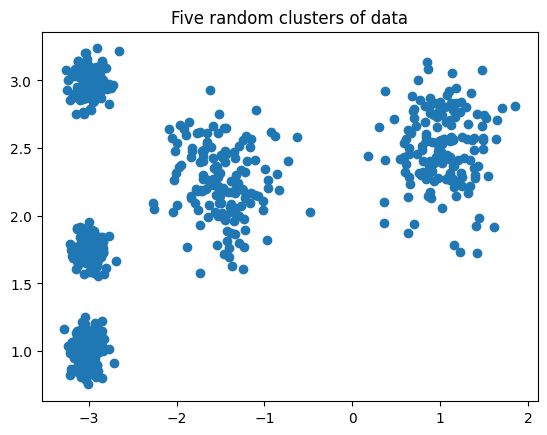

In [4]:
import numpy as np
from matplotlib import pyplot as plt
samples_per_cluster = 150
sigma = 0.1
#cluster 1
X1 = sigma * np.random.randn(samples_per_cluster) - 3
y1 = sigma * np.random.randn(samples_per_cluster) + 3

#cluster 2
X2 = sigma * np.random.randn(samples_per_cluster) - 3
y2 = sigma * np.random.randn(samples_per_cluster) + 1.75

#cluster 3
X3 = sigma * np.random.randn(samples_per_cluster) - 3
y3 = sigma * np.random.randn(samples_per_cluster) + 1

#cluster 4
X4 = 3 * sigma * np.random.randn(samples_per_cluster) - 1.5
y4 = 3 * sigma * np.random.randn(samples_per_cluster) + 2.25


#cluster 5
X5 = 3 * sigma * np.random.randn(samples_per_cluster) + 1
y5 = 3 * sigma * np.random.randn(samples_per_cluster) + 2.5

X = np.concatenate([X1, X2, X3, X4, X5])
y = np.concatenate([y1, y2, y3, y4, y5])
plt.scatter(X, y)
plt.title('Five random clusters of data')
plt.show()

In [5]:
from sklearn.cluster import KMeans
training_data = np.c_[X, y]
kmeans = KMeans(n_clusters = 5)
y_pred = kmeans.fit_predict(training_data)

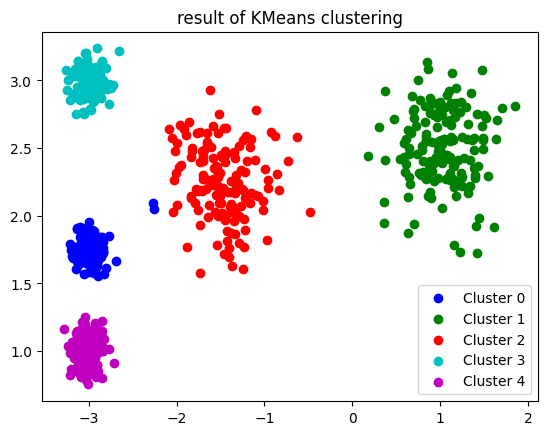

In [6]:
colors = [
    'b',
    'g',
    'r',
    'c',
    'm'
]

fig, axes = plt.subplots()
for i, color in enumerate(colors):
    axes.scatter(training_data[y_pred == i, 0], training_data[y_pred == i, 1], color = color, label = f'Cluster {i}')
axes.set_title('result of KMeans clustering')
axes.legend(loc = 'best')
plt.show()

You can use the _transform_ function to find the distance between the instance and each of the cluster centroids, which can be an efficient dimensionality reduction algorithm.

In [7]:
kmeans.transform(np.array([[0.1, 2.4]]))

array([[3.14509033, 0.92708891, 1.58302406, 3.14250258, 3.40695828]])

The above result shows that the distance between the input sample and the second cluster (0.91175746) is the lowest, which means that the instance belongs to that cluster.

KMeans works as follows:
1. Select random centroids to begin.
2. Label the instances with the same label as the centroid they are closest to.
3. Move the centroids toward the mean of the labeled instances.
4. Repeat steps 2 and 3 until the centroids stop moving. 

The initial position of the centroids can greatly affect the resulting model. If you are lucky, you can end up with a perfect model from the first try, but sometimes you don't. 

A solution to this problem is to run the KMeans algorithm multiple times and keep the best solution. This is the default behavior in scikit-learn as it run the KMeans algorithm 10 times and keeps the best solution.

the n_init parameter sets the number of the times the algorithm runs before it decides to keep the best solution.


In [8]:
#n_init sets the number of times the algorithm runs!
kmeans = KMeans(n_clusters = 5, n_init = 100)
kmeans.fit(np.expand_dims(X, -1))


KMeans(n_clusters=5, n_init=100)

The best solution is determined using the _inertia_, which is a metric that measures the average squared distance between each instance and its closest centroid. 

In [9]:
kmeans.inertia_

15.497858768627182

In [10]:
kmeans.score(np.expand_dims(X, -1))

-15.49785876862718

The score function returns a negative number because scikit-learn requires that the greater the number returned, the better the model is. 

There is a new version of KMeans called KMeans++, which improves the way the initial position for the centroids is chosen.

It works as follows:
1. Take the centroid chosen uniformly at random from the dataset.
2. Take a new centroid that is an instance chosen with a probability of: <br>$\frac{D(x^{(i)})^2}{\sum_{j = 1}^{m}D(x^{(j)})^2}$, where $D(x^{(i)})$ is the distance between the instance and the closest centroid that was already chosen. This probability ensures that instances farther away from already chosen centroids are much more likely to be selected as centroids. 
3. Repeat the previous step until all centroids have been chosen.  

This initialization method is the default that is used by scikit-learn!

## Mini-batch K-Means

The KMeans algorithm can be trained in mini-batches if the dataset doesn't fit into memory!

The following code demonstrates this:

In [11]:
from sklearn.cluster import MiniBatchKMeans
batch_size = 50
batches = [training_data[i:i+batch_size] for i in range(training_data.shape[0]//batch_size)]

mini_batch_kmeans = MiniBatchKMeans(n_clusters = 5)
for batch in batches:
    mini_batch_kmeans.partial_fit(batch)


You can also use the memmap class provided by numpy to map the data from the disk onto the RAM.

Mini-batch KMeans is faster than the regular implementation, but its inertia is generally worse.

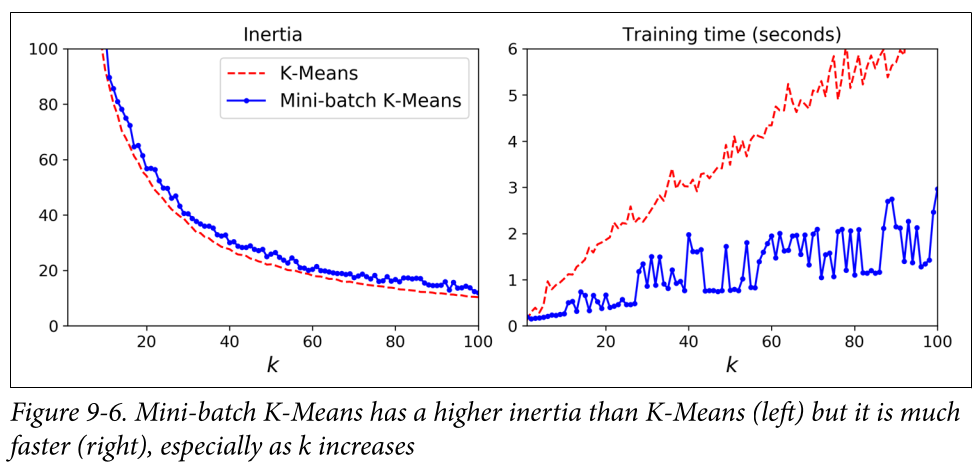

## Finding the optimal number of clusters

Finding the optimal number of clusters for KMeans is done by testing a range of clusters and plotting the resulting inertias for each model. 

The resulting curve is called an _elbow_ curve, and the point at which the elbow exists is approximately the optimal number of clusters for the problem at hand.

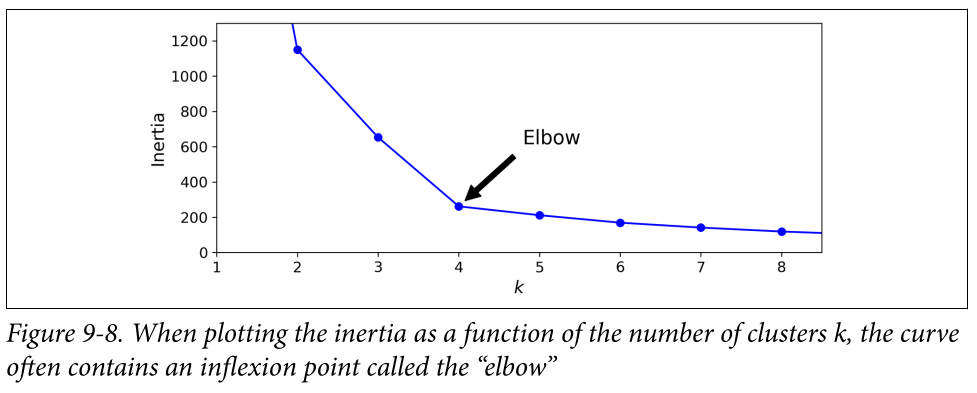

Alternatively, you can use the silhouette score to find the best number of clusters to use for KMeans.

The silhouette score is defined as:

silhouette score = $\frac{b-a}{max(a, b)}$

Where,<br>
b = the average distance to the instances of the closest cluster (excluding the cluster to which the sample belongs).<br>
a = the average distance to all instances of the same cluster.

__Note:__ The silhouette ranges from -1 to +1. +1 means that the instance is well inside its own cluster, while -1 means that the instance may have been assigned to the wrong cluster. A value of 0 means that the instance is close the cluster boundary.

In [12]:
from sklearn.metrics import silhouette_score
silhouette_score(np.expand_dims(X, -1), kmeans.labels_)

0.7611468980999019

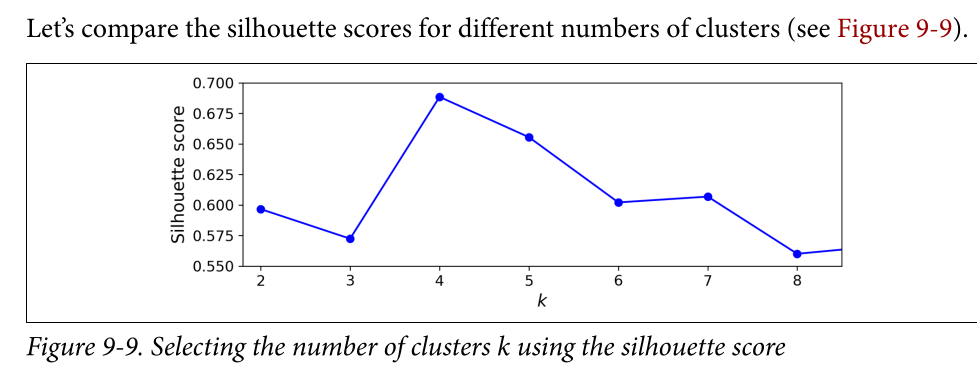

Problems with KMeans:
1. The need to run it multiple times to end up with the optimal solution.
2. The need to choose the number of clusters beforehand. 
3. It doesn't perform well on elliptical clusters. 

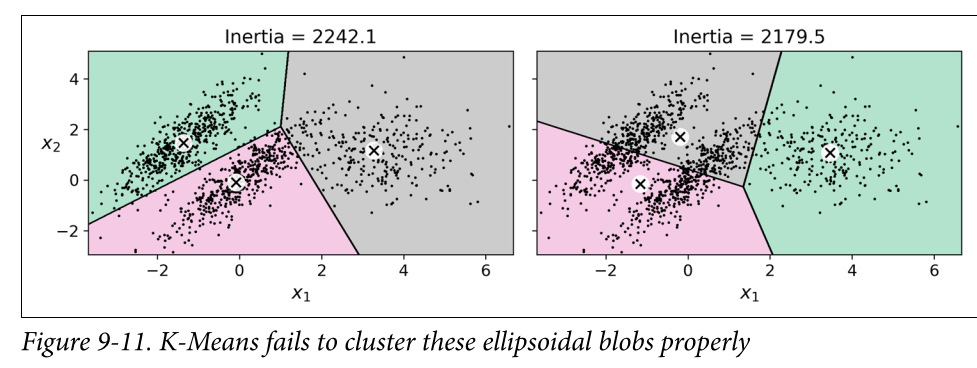

__Note:__ It is important to scale the input features before running KMeans. It doesn't guarantee that the input features will look spherical, but it will generally improve things.

## Clustering for image segmentation

In [13]:
import cv2
image = cv2.cvtColor(cv2.imread('images/image.jpg'), cv2.COLOR_BGR2RGB)
image.shape

(1080, 1920, 3)

In [14]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters = 8)
kmeans.fit(X)

KMeans()

In [15]:
segmented_image = kmeans.cluster_centers_[kmeans.labels_].reshape(image.shape).astype(np.uint8)

In [16]:
cv2.imshow('Original', image)
cv2.imshow('Segmented', segmented_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [17]:
images = [image]
for n_clusters in [10, 8, 6, 4, 2]:
    kmeans = KMeans(n_clusters = n_clusters).fit(X)
    segmented_image = kmeans.cluster_centers_[kmeans.labels_].reshape(image.shape).astype(np.uint8)
    images.append(segmented_image)

print(len(images))


6


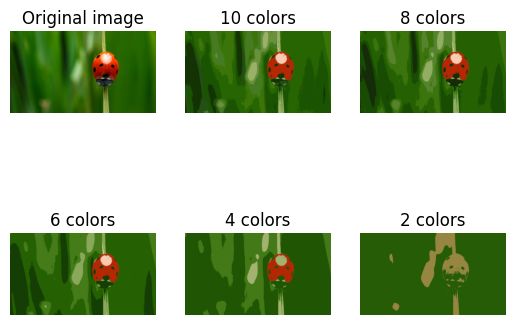

In [18]:
titles = [
    'Original image',
    '10 colors',
    '8 colors',
    '6 colors',
    '4 colors',
    '2 colors'
]
for i, image in enumerate(images):
    plt.subplot(2, 3, i+1).set_title(titles[i])
    plt.imshow(image)
    plt.axis('off')

plt.show()

## Clustering for Preprocessing

KMean can be used a preprocessing step for dimensionality reduction be replacing the original input features with the distances of each instance to the clusters created by KMeans.

The following code illustrates this:

In [19]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
X_digits, y_digits = load_digits(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, random_state = 0)


In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter = 1000000)
log_reg.fit(X_train, y_train)
log_reg.score(X_test, y_test)


0.9533333333333334

In [21]:
#Now let us use KMeans for preprocessing!
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('kmeans', KMeans(n_clusters = 50, max_iter = 1000000)),
    ('log_reg', LogisticRegression(max_iter = 1000000))
])

pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

0.9666666666666667

In [23]:
#test a range of values for the number of clusters using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'kmeans__n_clusters': range(50, 100)
}

grid_clf = GridSearchCV(pipeline, param_grid, cv = 3, verbose = 2)
grid_clf.fit(X_train, y_train)

grid_clf.score(X_test, y_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ..............................kmeans__n_clusters=50; total time=   0.7s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.5s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.5s
[CV] END ..............................kmeans__n_clusters=51; total time=   0.4s
[CV] END ..............................kmeans__n_clusters=51; total time=   0.4s
[CV] END ..............................kmeans__n_clusters=51; total time=   0.5s
[CV] END ..............................kmeans__n_clusters=52; total time=   0.5s
[CV] END ..............................kmeans__n_clusters=52; total time=   0.4s
[CV] END ..............................kmeans__n_clusters=52; total time=   0.8s
[CV] END ..............................kmeans__n_clusters=53; total time=   0.5s
[CV] END ..............................kmeans__n_clusters=53; total time=   0.4s
[CV] END ..............................kmeans__

0.9688888888888889

In [24]:
grid_clf.best_params_

{'kmeans__n_clusters': 80}

## Using Clustering for Semi-Supervised Learning

Semi-Supervised learning is when you have a few labeled instances and you want to propagate the labels from these instances in an automated way without having to do it manually.

KMeans can do this, and the following code demonstrates this:

In [25]:
#Say we only have 50 labeled instances!
n_labeled = 50
log_reg = LogisticRegression(max_iter = 1000000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.8311111111111111

In [26]:
#Let us cluster the training data and find 
#images that are close to the center of each cluster.
#These image are called "representative images", and 
#they are much better samples to train on instead of picking
#50 random images.

k = 50 # choose 50 representative images
kmeans = KMeans(n_clusters = k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis = 0)
X_representative_digits = X_train[representative_digit_idx]

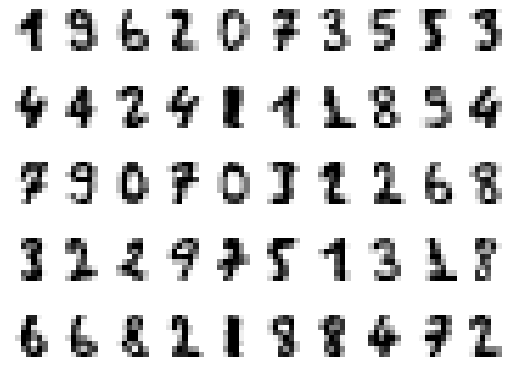

In [27]:
for i in range(50):
    plt.subplot(5, 10, i+1)
    plt.imshow(16 - X_representative_digits[i].reshape(8,8), cmap = plt.cm.gray)
    plt.axis('off')
plt.show()


In [32]:
#Now, let us manually label each image
y_representative_digits = np.array([4, 9, 6, 2, 0, 7, 3, 5, 5, 3, 4, 4, 2, 4, 1, 1, 1, 8, 9, 4, 7, 9, 0, 7, 0, 3, 2, 2, 6, 8, 3, 2, 2, 9, 7, 5, 1, 3, 1, 8, 6, 6, 8, 2, 1, 8, 8, 4, 7, 2])

In [33]:
#Now we have a dataset of 50 images that represent their cluster
#well instead of having 50 random image. 
log_reg = LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8355555555555556

We got a slightly better model after doing this!
Now, let us propagate the labels of these representative image to their entire clusters and see what happens.

In [34]:
y_train_propagated = np.zeros(len(X_train), dtype = np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [35]:
log_reg = LogisticRegression(max_iter = 1000000)
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.8888888888888888

We got an even better result!

Let us try to only select the 20% closest samples to centroid to propagate the labels to. 

We do that because some of the instances in each cluster are so close to the boundary that they end being mislabeled, so we only choose the ones that are reasonable close to the center of the cluster.

In [36]:
percentile_closest = 20
#get the lowest cluster distance of each sample
X_cluster_dist = np.min(X_digits_dist, axis = 1)

for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]


In [37]:
log_reg = LogisticRegression(max_iter = 1000000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)


0.8977777777777778

The next step in the training would be to use active learning to label the instances that the model is uncertain about.

This works as follows:
1. Train a model on the labeled instances and let it make predictions on the unlabeled instances.
2. The instances which the model is most uncertain about are given to a human expert to label them.
3. You iterate steps 1 and 2 until the performance improvement stops being worth the labeling effort.

You can also try another strategy which involves labeling the samples that have the highest impact on the models performance. These could be samples that are mislabeled often or ones that many different models disagree on. 

## DBSCAN

DBSCAN works as follows:
* For each instance, the algorithm counts how many instances are located within a small distance $\epsilon$ from it. This region is called the instances $\epsilon$-_neighborhood_. 
* If an instance has at least min_samples instances in its $\epsilon$-neighborhood (including itself), then it is considered a core instance. This means that core instance are located in dense regions.
* All instances in the neighborhood of a core instance belong to the same cluster. This neighborhood may include other core instances; therefore, a long sequence of neighboring core instances forms a single cluster. 
* Any instance that is not a core instance and does not have one its neighborhood is considered an anomaly. 

In [75]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 1000, noise = 0.05)
dbscan = DBSCAN(eps = 0.1, min_samples = 5)
dbscan.fit(X)

DBSCAN(eps=0.1)

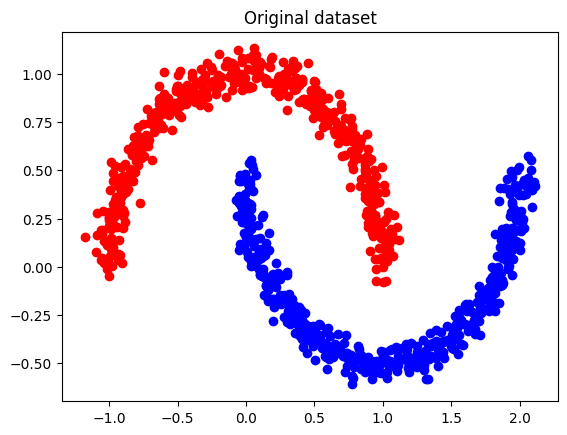

In [76]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], color = 'r')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color = 'b')
plt.title('Original dataset')
plt.show()

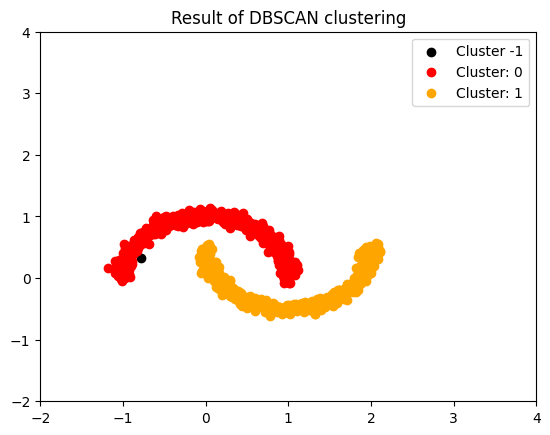

In [77]:
clusters = np.unique(dbscan.labels_)
colors_and_labels = [
    ('black', 'Cluster -1'),
    ('red', 'Cluster: 0'),
    ('orange', 'Cluster: 1'),
    ('yellow', 'Cluster: 2'),
    ('green', 'Cluster: 3'),
    ('blue', 'Cluster: 4'),
    ('purple', 'Cluster: 5'),
    ('pink', 'Cluster: 6'),
    ('cyan', 'Cluster: 7')
]


for i, cluster in enumerate(clusters):
    plt.scatter(X[dbscan.labels_ == clusters[i], 0], X[dbscan.labels_ == clusters[i], 1], color = colors_and_labels[i][0], label = str(colors_and_labels[i][1]))
plt.legend(loc = 'best')
plt.xlim([-2, 4])
plt.ylim([-2, 4])
plt.title('Result of DBSCAN clustering')
plt.show()

__Notes:__ 
1. DBSCAN doesn't have a predict function, which means that it cannot predict new instances. However, it has a fit_predict() function, which enables it to fit the data and predict it at the same time.
2. You can train a classifier that takes in the core components of the DBSCAN algorithm as input and the clusters they belong to as the output. This new classifier is able to predict the cluster to which a new instance belongs. 



In [80]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])


KNeighborsClassifier(n_neighbors=50)

In [81]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([0, 1, 0, 1])

In [82]:
knn.predict_proba(X_new)

array([[0.72, 0.28],
       [0.  , 1.  ],
       [0.86, 0.14],
       [0.  , 1.  ]])

In the previous example, we trained the classifier only on the core instances. However, we could have trained it on all the instances or all of them except for the anomalies. The choice depends on the task.

### Other clustering algorithms

1. Agglomerative clustering.
2. BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies).
3. Mean-Shift.
4. Affinity Propagation.
5. Spectral Clustering.

You can get more information about these algorithms on the internet and on scikit-learns website. 

## Gaussian Mixtures